In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import json
import pickle
import joblib
import os

In [2]:
# Load engineered data
df = pd.read_csv('../data/features/engineered_features.csv')
print(f"Loaded: {df.shape}")



Loaded: (69, 482)


In [4]:
# Define target
TARGET = 'Lowest_20%_Petrol, diesel and oils'  
print(f"Target: {TARGET}")

# Verify target exists
if TARGET not in df.columns:
    print(f"\nERROR: '{TARGET}' not found!")
    print("\nAvailable targets you can use:")
    available = [col for col in df.columns if any(x in col for x in ['fuel_ratio', 'total_spend', 'Electricity', 'Gas', 'Petrol'])]
    for col in available[:10]:
        print(f"  • {col}")
    raise KeyError(f"Target '{TARGET}' not found. Please choose from the list above.")
else:
    print(f"✅ Target column found!")

Target: Lowest_20%_Petrol, diesel and oils
✅ Target column found!


In [5]:
# Prepare Data
print("PREPARING DATA...")

# Separate features and target
exclude_cols = ['year_month', 'date', TARGET]
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df[TARGET]

# Handle missing values
X = X.fillna(method='ffill').fillna(method='bfill').fillna(0)

# Remove constant features
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_cols)

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

PREPARING DATA...
Features: 462
Samples: 69


CORRELATION ANALYSIS...

Top 20 features by correlation:


,feature,correlation,abs_correlation
Third_10%_Petrol,Third_10%_Petrol,0.958294,0.958294
Lowest_10%_Diesel,Lowest_10%_Diesel,0.941004,0.941004
Second_10%_Petrol,Second_10%_Petrol,0.939626,0.939626
Fourth_10%_Diesel,Fourth_10%_Diesel,0.938440,0.938440
fuel_spend_ratio_Highest_20%,fuel_spend_ratio_Highest_20%,0.936685,0.936685
Middle_20%_Vehicle purchase,Middle_20%_Vehicle purchase,0.933771,0.933771
Seventh_10%_Petrol,Seventh_10%_Petrol,0.923582,0.923582
Third_10%_Diesel,Third_10%_Diesel,0.918293,0.918293
Fifth_10%_Diesel,Fifth_10%_Diesel,0.900309,0.900309
Ninth_10%_Petrol,Ninth_10%_Petrol,0.896087,0.896087


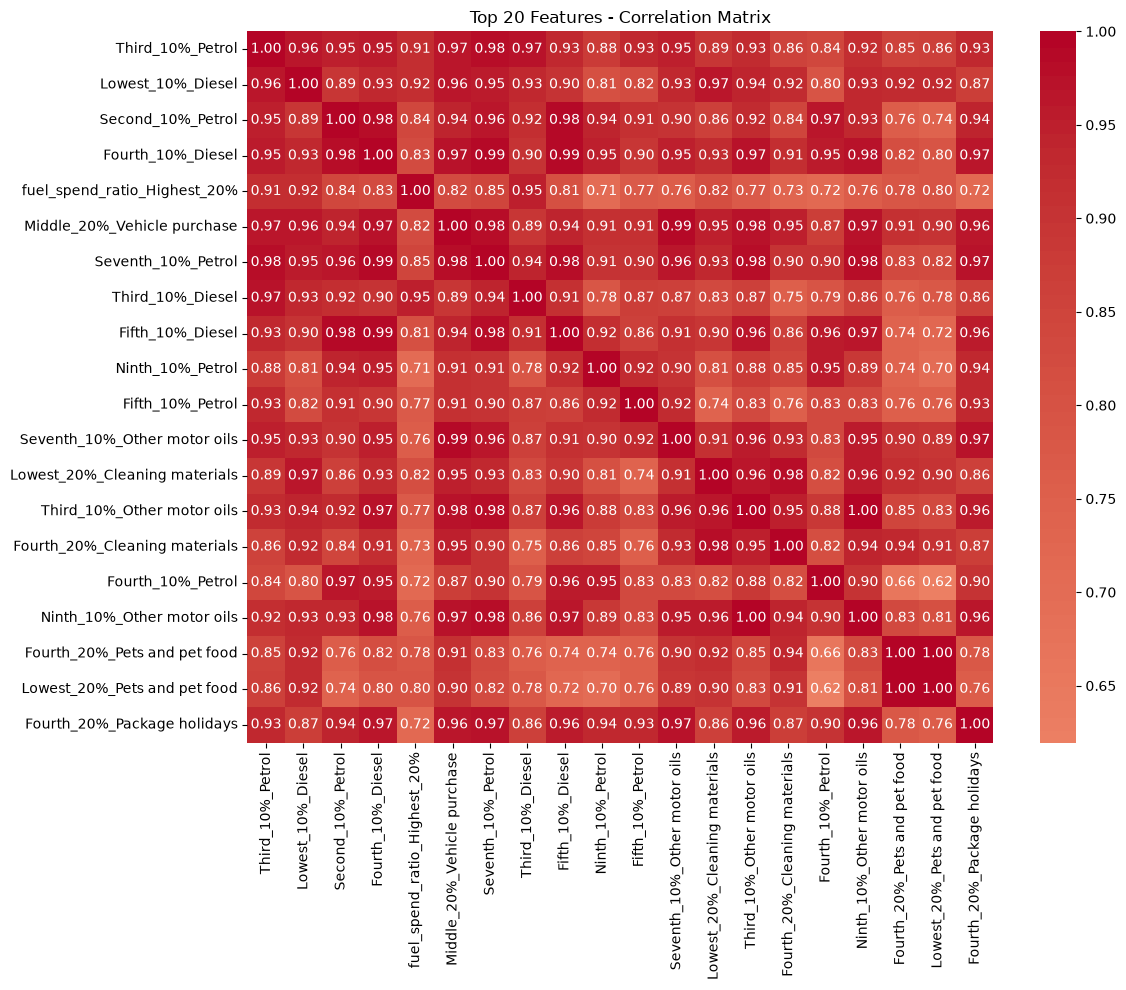

In [7]:
# Correlation Analysis
print("CORRELATION ANALYSIS...")

# Correlation with target
correlations = pd.DataFrame({
    'feature': X.columns,
    'correlation': X.corrwith(y),
    'abs_correlation': X.corrwith(y).abs()
}).sort_values('abs_correlation', ascending=False)

print("\nTop 20 features by correlation:")
display(correlations.head(20))
os.makedirs('../data/selected', exist_ok=True)
# Visualize correlation heatmap (top 20)
plt.figure(figsize=(12, 10))
top_corr_features = correlations.head(20)['feature'].tolist()
corr_matrix = X[top_corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Top 20 Features - Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/selected/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Save correlation analysis
correlations.to_csv('../data/selected/correlation_analysis.csv', index=False)

In [8]:
# Filter Methods
print("FILTER METHODS...")

#  Variance threshold (remove low variance)
from sklearn.feature_selection import VarianceThreshold
selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X)
var_selected = X.columns[selector_var.get_support()].tolist()
print(f"Variance threshold selected: {len(var_selected)} features")

#  SelectKBest with f_regression
selector_f = SelectKBest(f_regression, k=20)
X_f = selector_f.fit_transform(X, y)
f_selected = X.columns[selector_f.get_support()].tolist()
print(f"SelectKBest (f_regression) selected: {len(f_selected)} features")

#  Mutual Information
selector_mi = SelectKBest(mutual_info_regression, k=20)
X_mi = selector_mi.fit_transform(X, y)
mi_selected = X.columns[selector_mi.get_support()].tolist()
print(f"Mutual Information selected: {len(mi_selected)} features")

# Combined filter results
filter_features = {
    'variance': var_selected,
    'f_regression': f_selected,
    'mutual_info': mi_selected
}


FILTER METHODS...
Variance threshold selected: 403 features
SelectKBest (f_regression) selected: 20 features
Mutual Information selected: 20 features


In [9]:
# Wrapper Methods
print("🔄 WRAPPER METHODS (RFE)...")

# Scale data for RFE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# RFE with Random Forest (use only top 30 from correlation)
top_30_features = correlations.head(30)['feature'].tolist()
X_top30 = X[top_30_features]

# RFE
estimator = RandomForestRegressor(n_estimators=50, random_state=42)
rfe = RFE(estimator, n_features_to_select=10, step=1)
rfe.fit(X_top30, y)
rfe_selected = X_top30.columns[rfe.support_].tolist()
print(f"RFE selected: {len(rfe_selected)} features")
print(f"Features: {rfe_selected}")

🔄 WRAPPER METHODS (RFE)...
RFE selected: 10 features
Features: ['Third_10%_Petrol', 'Lowest_10%_Diesel', 'Second_10%_Petrol', 'fuel_spend_ratio_Highest_20%', 'Middle_20%_Vehicle purchase', 'Seventh_10%_Petrol', 'Third_10%_Diesel', 'Fifth_10%_Diesel', 'Seventh_10%_Other motor oils', 'Fourth_20%_Cleaning materials']


In [10]:
# Embedded Methods
print("EMBEDDED METHODS...")

# Random Forest Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Random Forest features:")
display(rf_importance.head(10))

rf_selected = rf_importance.head(15)['feature'].tolist()

# Lasso with CV
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

lasso_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_
}).sort_values('coefficient', ascending=False)

lasso_selected = lasso_importance[lasso_importance['coefficient'] != 0]['feature'].tolist()
print(f"\nLasso selected: {len(lasso_selected)} features")

# Save importance scores
rf_importance.to_csv('../data/selected/rf_importance.csv', index=False)
lasso_importance.to_csv('../data/selected/lasso_importance.csv', index=False)

EMBEDDED METHODS...

Top 10 Random Forest features:


,feature,importance
332,Fourth_10%_Diesel,0.041572
349,Seventh_10%_Petrol,0.038722
346,Second_10%_Petrol,0.037519
207,Middle_20%_Vehicle purchase,0.033000
355,Third_10%_Petrol,0.031848
353,Third_10%_Diesel,0.030043
38,Fourth_20%_Cleaning materials,0.029616
338,Lowest_10%_Diesel,0.023163
122,Lowest_20%_Cleaning materials,0.016205
448,Highest_20%_transport_share,0.015606



Lasso selected: 5 features


In [11]:
# Final Selection - Voting Strategy
print("FINAL FEATURE SELECTION (VOTING)")

# Collect all selections
all_selections = {
    'correlation': correlations.head(15)['feature'].tolist(),
    'f_regression': f_selected,
    'mutual_info': mi_selected,
    'rfe': rfe_selected,
    'rf': rf_selected,
    'lasso': lasso_selected
}

# Count votes
vote_counts = {}
for method, features in all_selections.items():
    for feature in features:
        vote_counts[feature] = vote_counts.get(feature, 0) + 1

vote_df = pd.DataFrame({
    'feature': list(vote_counts.keys()),
    'votes': list(vote_counts.values())
}).sort_values('votes', ascending=False)

print("\nVoting results:")
print(vote_df['votes'].value_counts().sort_index(ascending=False))

# Select features with 3+ votes
selected_features = vote_df[vote_df['votes'] >= 3]['feature'].tolist()

# If too few, add top correlation features
if len(selected_features) < 5:
    additional = correlations[~correlations['feature'].isin(selected_features)].head(5 - len(selected_features))['feature'].tolist()
    selected_features.extend(additional)

print(f"\n✅ FINAL SELECTED FEATURES: {len(selected_features)}")
print(f"Features: {selected_features}")

FINAL FEATURE SELECTION (VOTING)

Voting results:
votes
6     1
5     1
4     7
3     4
2     3
1    28
Name: count, dtype: int64

✅ FINAL SELECTED FEATURES: 13
Features: ['Second_10%_Petrol', 'fuel_spend_ratio_Highest_20%', 'Lowest_10%_Diesel', 'Third_10%_Petrol', 'Fourth_10%_Diesel', 'Middle_20%_Vehicle purchase', 'Seventh_10%_Petrol', 'Third_10%_Diesel', 'Fourth_20%_Cleaning materials', 'Fifth_10%_Diesel', 'Seventh_10%_Other motor oils', 'Ninth_10%_Petrol', 'Lowest_20%_Cleaning materials']


CREATING FINAL SELECTED DATASET...


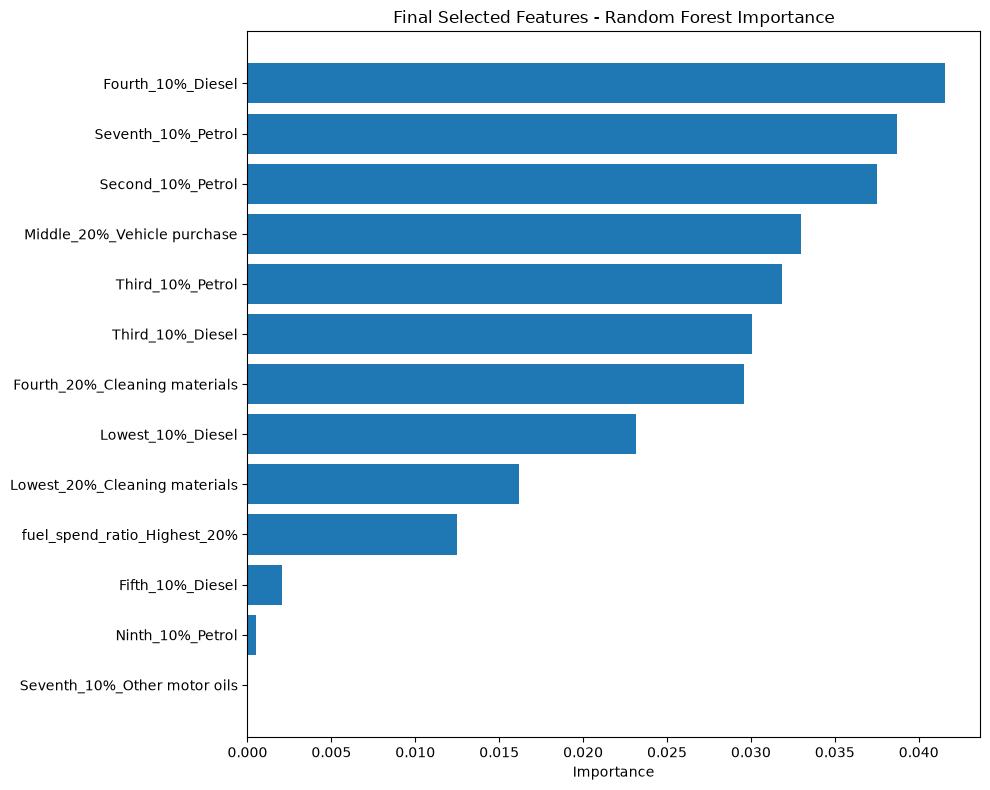

   Selected: 13 features
   Saved to: ../data/selected/


In [15]:
# Final Dataset with Selected Features
print("CREATING FINAL SELECTED DATASET...")

# Create final dataset
X_selected = X[selected_features]

# Save selected features
os.makedirs('../data/selected', exist_ok=True)

# Save in multiple formats
X_selected.to_csv('../data/selected/selected_features.csv', index=False)
X_selected.to_parquet('../data/selected/selected_features.parquet', index=False)
X_selected.to_pickle('../data/selected/selected_features.pkl')

# Save feature list
with open('../data/selected/selected_features.json', 'w') as f:
    json.dump({
        'features': selected_features,
        'count': len(selected_features),
        'selection_method': 'voting (3+ methods)',
        'timestamp': datetime.now().isoformat()
    }, f, indent=2)

# Save selection report
selection_report = {
    'total_features_available': X.shape[1],
    'selected_features': len(selected_features),
    'feature_list': selected_features,
    'selection_methods': {
        'correlation': len(all_selections['correlation']),
        'f_regression': len(all_selections['f_regression']),
        'mutual_info': len(all_selections['mutual_info']),
        'rfe': len(all_selections['rfe']),
        'random_forest': len(all_selections['rf']),
        'lasso': len(all_selections['lasso'])
    },
    'voting_results': vote_df['votes'].value_counts().to_dict()
}

with open('../data/selected/selection_report.json', 'w') as f:
    json.dump(selection_report, f, indent=2)

# Visualize final selected features
plt.figure(figsize=(10, 8))
importance = rf_importance[rf_importance['feature'].isin(selected_features)]
importance = importance.sort_values('importance')
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Final Selected Features - Random Forest Importance')
plt.tight_layout()
plt.savefig('../data/selected/final_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


print(f"   Selected: {len(selected_features)} features")
print(f"   Saved to: ../data/selected/")